# Market Basket Analysis with Association Rules

## Which combinations are more than popular

This notebook turns a month of grocery baskets into a short list of product rules. Each rule has a direction, a count, and a comparison against what independence would have produced. The list is an input to shelf layout, bundles, and coupons.


## 1. Business framing

A **basket** is one shopping trip. An **association rule** $X \Rightarrow Y$ says that when the categories in $X$ are already in the basket, the categories in $Y$ are there too, more often than $Y$'s overall popularity would suggest.

A useful rule names an action:

- place the consequent on the way from the antecedent's aisle;
- offer the pair as one bundle;
- coupon the product the shopper does not yet have, once the antecedent is in the basket.

The same output is the wrong tool for a different question. Next-purchase models need a customer id and a clock. A price test is what shows that a bundle changes profit. This lecture stays with anonymous trips and with co-occurrence.

### Learning goals

By the end, you will be able to:

1. read $X \Rightarrow Y$ as a direction, and compute the other direction separately;
2. calculate support, confidence, lift, and leverage from basket counts;
3. explain why the Apriori principle makes the search finite, and why FP-Growth is the algorithm we run;
4. build a boolean basket matrix without turning blank export cells into a fake product;
5. drop high-confidence rules that only rediscover a popular category;
6. turn two or three surviving rules into a merchandising note, including the rule you would leave alone.

**Data:** the Groceries dataset distributed with the R package `arules` (Michael Hahsler, Kurt Hornik, Thomas Reutterer): 30 days of point-of-sale data from one grocery outlet, aggregated to 169 categories. A local `data/groceries.csv` is used when it exists. Otherwise the notebook downloads the public raw file shipped with *Machine Learning with R*.


## 2. Four numbers, from one small store

Notation for a rule $X \Rightarrow Y$:

$$
\mathrm{support}(X \Rightarrow Y) = \frac{\mathrm{count}(X \cup Y)}{N}
$$

$$
\mathrm{confidence}(X \Rightarrow Y) = \frac{\mathrm{count}(X \cup Y)}{\mathrm{count}(X)}
$$

$$
\mathrm{lift}(X \Rightarrow Y) = \frac{\mathrm{confidence}(X \Rightarrow Y)}{\mathrm{support}(Y)} = \frac{\mathrm{support}(X \cup Y)}{\mathrm{support}(X)\,\mathrm{support}(Y)}
$$

$$
\mathrm{leverage}(X \Rightarrow Y) = \mathrm{support}(X \cup Y) - \mathrm{support}(X)\,\mathrm{support}(Y)
$$

Sure — in simpler terms:
- Support = how often X and Y appear together in all baskets.
- Confidence = when X appears, how often Y also appears.
- Lift = tells you whether X and Y appear together more often than we would normally expect.
  - Lift = 1 → no special relationship
  - Lift > 1 → they appear together more often than expected
  - Lift < 1 → they appear together less often than expected
- Leverage = the actual extra proportion of baskets where X and Y appear together compared with what we'd expect by chance.
- Leverage × N = approximately how many extra baskets contain X and Y together.

Lift is symmetric: $\mathrm{lift}(X \Rightarrow Y) = \mathrm{lift}(Y \Rightarrow X)$. Confidence is not. The direction you act on is the direction with usable confidence.

Work the arithmetic on 1,000 invented baskets before touching the file.

| | Baskets |
|---|---:|
| Hot dogs | 200 |
| Relish | 50 |
| Both | 40 |
| All baskets | 1,000 |

Independence would put both items in $0.20 \times 0.05 \times 1000 = 10$ baskets. The table has 40. The next cell checks the four summaries: confidence 0.80 one way, 0.20 the other way, lift 4, and 30 extra baskets per 1,000.


In [1]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython import get_ipython
from IPython.display import display
from mlxtend.frequent_patterns import association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import mlxtend

get_ipython().run_line_magic("matplotlib", "inline")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_colwidth", 80)

ACCENT = "#1f4b73"
print(f"pandas {pd.__version__} | mlxtend {mlxtend.__version__}")


pandas 2.3.3 | mlxtend 0.23.4


In [2]:
n_example = 1_000
count_hot_dogs = 200
count_relish = 50
count_both = 40

confidence_relish_to_hot_dogs = count_both / count_relish
confidence_hot_dogs_to_relish = count_both / count_hot_dogs
# Integer form of lift: (joint / N) / ((count_X / N) * (count_Y / N)).
lift_pair = (count_both * n_example) / (count_hot_dogs * count_relish)
expected_both = count_hot_dogs * count_relish / n_example
extra_baskets = count_both - expected_both

example = pd.Series(
    {
        "confidence  relish → hot dogs": confidence_relish_to_hot_dogs,
        "confidence  hot dogs → relish": confidence_hot_dogs_to_relish,
        "lift (either direction)": lift_pair,
        "extra baskets per 1,000": extra_baskets,
    }
)
assert confidence_relish_to_hot_dogs == 0.80
assert confidence_hot_dogs_to_relish == 0.20
assert lift_pair == 4
assert extra_baskets == 30
example.map(lambda value: f"{value:.2f}")


confidence  relish → hot dogs     0.80
confidence  hot dogs → relish     0.20
lift (either direction)           4.00
extra baskets per 1,000          30.00
dtype: object

## 3. Why the search does not list every combination

This file has 169 categories. The power set is $2^{169}$ itemsets, which is not a procedure. Two facts make a search possible.

**The Apriori principle.** If an itemset is rare, every larger itemset that contains it is rare too. Fix a minimum count first. Any category below that count is dropped, and every pair that would have included it is never counted. The algorithm then builds triples only from pairs that themselves cleared the floor, and stops when a level produces nothing new.

**FP-Growth** uses that same principle and stores the baskets in a prefix tree, so it does not materialize the candidate pairs Apriori would generate and then delete. On a month from one store the two algorithms return the same frequent itemsets. FP-Growth is the one to run; `mlxtend.frequent_patterns.apriori` is the same function signature if you want the level-wise version side by side.

The thresholds are store decisions, set before you look at the winning rule:

- **Minimum support** is "often enough to matter on a shelf." Here, 1% of 9,835 baskets is at least 99 trips, about three a day.
- **Minimum confidence** is "often enough to act once the antecedent is in the basket." We will use 30%.
- **Minimum lift** is "clearly above the base rate." We will use 1.5.

A confidence of 30% on an item that is already in 30% of baskets is lift 1. That rule does not earn a display.


## 4. The baskets

Each line of the file is one trip. Tokens are category names separated by commas. There is no customer id, price, quantity, or timestamp on the line. The only calendar fact we use is the one from the data documentation: 30 consecutive days, one outlet.

A wide spreadsheet with columns `Item 1`, `Item 2`, … is a poor input for this job. Short baskets leave blank cells, and those blanks are empty positions in the export. Column order is also an export artifact, so the frequency of `Item 1` is not the popularity of a product. Popularity is the share of baskets that contain the category, wherever it sat on the line.


In [3]:
LOCAL_PATHS = [Path("data/groceries.csv"), Path("groceries.csv")]
DATA_URL = (
    "https://raw.githubusercontent.com/stedy/"
    "Machine-Learning-with-R-datasets/master/groceries.csv"
)

local_path = next((path for path in LOCAL_PATHS if path.exists()), None)
if local_path is None:
    local_path = Path("data/groceries.csv")
    local_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, local_path)
    data_source = DATA_URL
else:
    data_source = local_path

raw_lines = local_path.read_text(encoding="utf-8").splitlines()
baskets = [
    [item for item in line.split(",") if item]
    for line in raw_lines
    if line.strip()
]
n_categories = len({item for basket in baskets for item in basket})
print(f"Loaded {len(baskets):,} baskets and {n_categories} categories from {data_source}")
print("First basket:", baskets[0])
assert len(baskets) == 9835, "Expected the Groceries file: 9,835 baskets."
assert n_categories == 169, "Expected 169 aggregated categories."


Loaded 9,835 baskets and 169 categories from data\groceries.csv
First basket: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']


Basket size: median 3, mean 4.4, max 32
Single-category baskets: 2,159 (no pair can come from these)
Share of True cells in the matrix: 2.6%
Whole milk is in 25.6% of baskets


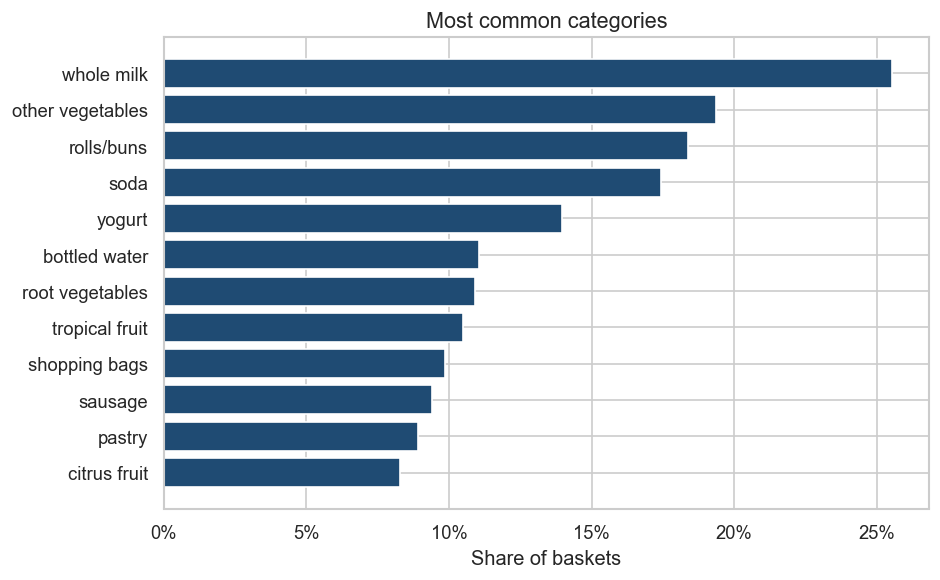

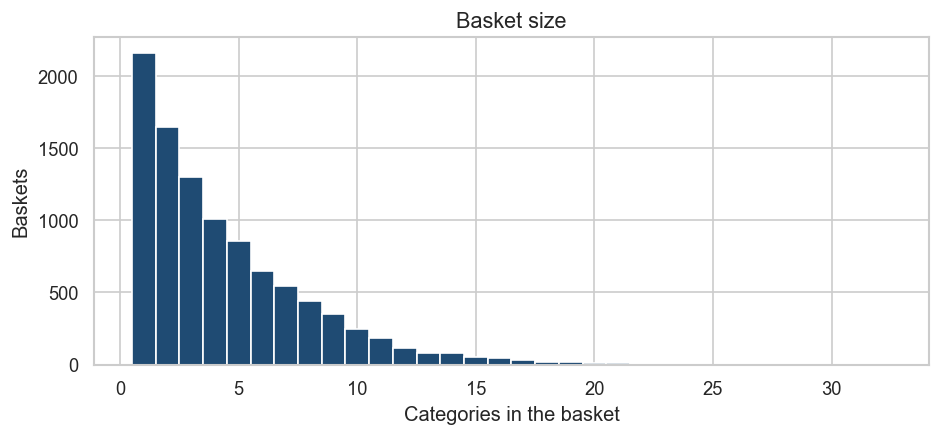

In [4]:
te = TransactionEncoder()
basket = pd.DataFrame(
    te.fit(baskets).transform(baskets),
    columns=te.columns_,
    dtype=bool,
)
assert "nan" not in basket.columns
assert basket.shape == (9835, 169)

sizes = pd.Series([len(items) for items in baskets], name="basket_size")
print(
    f"Basket size: median {sizes.median():.0f}, "
    f"mean {sizes.mean():.1f}, max {int(sizes.max())}"
)
print(f"Single-category baskets: {int((sizes == 1).sum()):,} (no pair can come from these)")
print(f"Share of True cells in the matrix: {basket.to_numpy().mean():.1%}")
print(f"Whole milk is in {basket['whole milk'].mean():.1%} of baskets")

top_items = basket.mean().sort_values(ascending=False).head(12).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_items.index, top_items.values, color=ACCENT)
ax.set_xlabel("Share of baskets")
ax.set_title("Most common categories")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(
    sizes,
    bins=range(1, int(sizes.max()) + 2),
    color=ACCENT,
    align="left",
    edgecolor="white",
)
ax.set_xlabel("Categories in the basket")
ax.set_ylabel("Baskets")
ax.set_title("Basket size")
fig.tight_layout()
plt.show()


Whole milk is in about one basket in four. Any rule whose consequent is whole milk starts with a confidence near 26% even when the antecedent is irrelevant. The median basket holds a few categories, and the single-category trips printed above cannot produce a pair, so most cells in the matrix are `False`. That sparsity is normal. It is also why we mine itemsets instead of correlating all 169 columns by hand.

The boolean frame records presence. A category bought twice in one trip is still a single `True`. Quantity and price are a later join, once a shortlist of rules exists.


## 5. Two rules, counted directly

The helper below is the definitions from section 2, applied to columns of the boolean frame. Use it whenever a mined table needs to be checked against raw counts.

The first rule is the one worth a shelf conversation: **beef → root vegetables**. The second is the trap: **bottled beer → whole milk**. Beer buyers look "likely" to buy milk if you only read confidence.


In [5]:
def rule_metrics(frame, antecedent, consequent):
    # Support, confidence, lift, and leverage from boolean basket columns.
    left = frame[list(antecedent)].all(axis=1)
    right = frame[list(consequent)].all(axis=1)
    both = left & right
    n = len(frame)
    antecedent_count = int(left.sum())
    consequent_count = int(right.sum())
    joint_count = int(both.sum())
    support_x = antecedent_count / n
    support_y = consequent_count / n
    support = joint_count / n
    confidence = joint_count / antecedent_count
    return pd.Series(
        {
            "antecedent_count": antecedent_count,
            "consequent_count": consequent_count,
            "joint_count": joint_count,
            "support": support,
            "confidence": confidence,
            "lift": confidence / support_y,
            "extra_baskets": joint_count - (antecedent_count * consequent_count / n),
        }
    )


def describe_rule(frame, antecedent, consequent):
    metrics = rule_metrics(frame, antecedent, consequent)
    condition = " + ".join(antecedent)
    outcome = " + ".join(consequent)
    extra = float(metrics["extra_baskets"])
    extra_text = (
        f"{extra:.0f} extra baskets versus independence"
        if extra >= 0
        else f"{abs(extra):.0f} fewer baskets than independence"
    )
    print(
        f"{condition} → {outcome}: "
        f"{int(metrics['joint_count'])} of the {int(metrics['antecedent_count'])} baskets "
        f"with {condition} also contain {outcome} "
        f"(confidence {metrics['confidence']:.1%}). "
        f"Base rate of {outcome}: {metrics['consequent_count'] / len(frame):.1%}. "
        f"Lift {metrics['lift']:.2f} ({extra_text})."
    )
    return metrics


beef = describe_rule(basket, ["beef"], ["root vegetables"])
beef_reverse = describe_rule(basket, ["root vegetables"], ["beef"])
beer = describe_rule(basket, ["bottled beer"], ["whole milk"])

assert beef["joint_count"] == 171
assert beef["antecedent_count"] == 516
assert beef["consequent_count"] == 1072
assert abs(beef["lift"] - 3.04) < 0.01
assert abs(beef_reverse["lift"] - beef["lift"]) < 1e-9
assert beef_reverse["confidence"] < 0.20
assert beer["joint_count"] == 201
assert beer["lift"] < 1


beef → root vegetables: 171 of the 516 baskets with beef also contain root vegetables (confidence 33.1%). Base rate of root vegetables: 10.9%. Lift 3.04 (115 extra baskets versus independence).
root vegetables → beef: 171 of the 1072 baskets with root vegetables also contain beef (confidence 16.0%). Base rate of beef: 5.2%. Lift 3.04 (115 extra baskets versus independence).
bottled beer → whole milk: 201 of the 792 baskets with bottled beer also contain whole milk (confidence 25.4%). Base rate of whole milk: 25.6%. Lift 0.99 (1 fewer baskets than independence).


**Beef → root vegetables** clears a merchandising bar. Root vegetables are in 171 of the 516 baskets that contain beef (confidence 33%). On their own they are in 1,072 of 9,835 baskets (11%). Lift is 3.04. Independence would have produced about 56 joint baskets; the file has 171, which is about 115 extra trips in the month.

**Root vegetables → beef** has the same lift and a confidence of 16%. The pair is real in both directions. The direction you can act on, once beef is in the basket, is toward root vegetables: the meat case, then the vegetables that go in the pot. The category is already aggregated (carrots, onions, potatoes, and the rest), so a planogram change still needs the SKU file.

**Bottled beer → whole milk** has confidence 25% (201 of 792). Whole milk is already in 2,513 baskets, 25.6% of the store. Lift is 0.99. A ranking by confidence promotes this pair. A ranking by lift leaves it out. Beer buyers purchase milk at the store's usual rate.


## 6. Mine the month

`fpgrowth` returns every itemset at or above the support floor. `association_rules` splits each itemset into antecedent and consequent and computes the metrics. Antecedent and consequent stay in separate columns, so the direction is part of the result rather than something we guess from an unordered pair.

We then keep rules with confidence at least 30% and lift at least 1.5. The beef rule survives. The beer rule does not.


333 frequent itemsets at support >= 1%


,itemsets
size,
1,88
2,213
3,32


108 rules with lift >= 1.5 and confidence >= 30%


,if,then,baskets,confidence,lift,extra baskets
0,"citrus fruit, other vegetables",root vegetables,102,35.9%,3.30,71
1,"other vegetables, tropical fruit",root vegetables,121,34.3%,3.14,83
2,beef,root vegetables,171,33.1%,3.04,115
3,"citrus fruit, root vegetables",other vegetables,102,58.6%,3.03,68
4,"root vegetables, tropical fruit",other vegetables,121,58.5%,3.02,81
5,"other vegetables, whole milk",root vegetables,228,31.0%,2.84,148
6,"curd, whole milk",yogurt,99,38.5%,2.76,63
7,"rolls/buns, root vegetables",other vegetables,120,50.2%,2.59,74
8,"root vegetables, yogurt",other vegetables,127,50.0%,2.58,78
9,"tropical fruit, whole milk",yogurt,149,35.8%,2.57,91


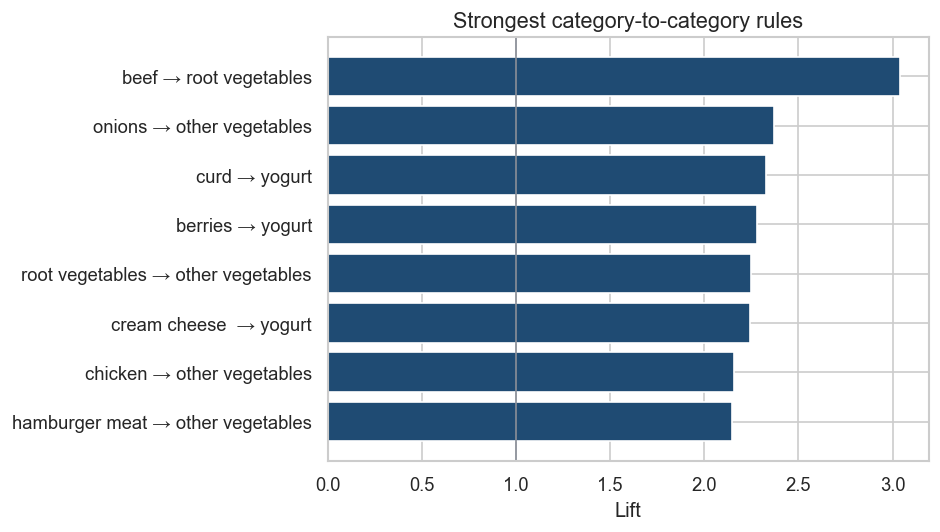

In [6]:
MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.30
MIN_LIFT = 1.5

# apriori(...) is a drop-in replacement if you want the level-wise search.
frequent = fpgrowth(basket, min_support=MIN_SUPPORT, use_colnames=True)
frequent["size"] = frequent["itemsets"].map(len)
print(f"{len(frequent):,} frequent itemsets at support >= {MIN_SUPPORT:.0%}")
display(frequent["size"].value_counts().sort_index().rename("itemsets").to_frame())

rules = association_rules(frequent, metric="lift", min_threshold=MIN_LIFT)
rules = rules.loc[rules["confidence"] >= MIN_CONFIDENCE].copy()
print(
    f"{len(rules):,} rules with lift >= {MIN_LIFT} "
    f"and confidence >= {MIN_CONFIDENCE:.0%}"
)

beef_kept = rules["antecedents"].map(lambda items: items == frozenset({"beef"})) & rules[
    "consequents"
].map(lambda items: items == frozenset({"root vegetables"}))
assert beef_kept.any(), "The beef rule should survive these thresholds."


def present_rules(frame, n_baskets, limit=12):
    view = frame.copy()
    view["if"] = view["antecedents"].map(lambda items: ", ".join(sorted(items)))
    view["then"] = view["consequents"].map(lambda items: ", ".join(sorted(items)))
    view["baskets"] = (view["support"] * n_baskets).round().astype(int)
    view["extra baskets"] = (view["leverage"] * n_baskets).round().astype(int)
    view = view.sort_values(["lift", "confidence"], ascending=False).head(limit)
    shown = (
        view[["if", "then", "baskets", "confidence", "lift", "extra baskets"]]
        .reset_index(drop=True)
    )
    shown["confidence"] = shown["confidence"].map(lambda value: f"{value:.1%}")
    shown["lift"] = shown["lift"].map(lambda value: f"{value:.2f}")
    return shown


display(present_rules(rules, len(basket)))

pair_rules = rules.loc[
    rules["antecedents"].map(len).eq(1) & rules["consequents"].map(len).eq(1)
].sort_values("lift", ascending=False).head(8)
labels = [
    f"{next(iter(antecedent))} → {next(iter(consequent))}"
    for antecedent, consequent in zip(pair_rules["antecedents"], pair_rules["consequents"])
]
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(labels[::-1], pair_rules["lift"].iloc[::-1], color=ACCENT)
ax.axvline(1, color="#8a8f98", linewidth=1)
ax.set_xlabel("Lift")
ax.set_title("Strongest category-to-category rules")
fig.tight_layout()
plt.show()


The highest lift in that filtered list is citrus fruit and other vegetables together, then root vegetables: 102 baskets, lift 3.30. Beef → root vegetables is the strongest rule that involves only two categories, which is why the walkthrough above uses it. Rules with a two-category antecedent are more specific and usually rest on fewer baskets, so read the basket count before proposing a three-item bundle.

The strongest rule that *ends* in whole milk is still a dairy rule: curd and yogurt together, then milk. It is in the mined set (99 baskets, confidence 58%, lift 2.28). Both conditions are already in the dairy case. That can support a dairy bundle. It is a weak reason to move the milk case across the store: the shopper who triggered the rule is already there. The next cell locks those counts.


In [7]:
dairy = describe_rule(basket, ["curd", "yogurt"], ["whole milk"])
assert dairy["antecedent_count"] == 170
assert dairy["joint_count"] == 99
assert abs(dairy["lift"] - 2.28) < 0.01
dairy_in_rules = rules["antecedents"].map(
    lambda items: items == frozenset({"curd", "yogurt"})
) & rules["consequents"].map(lambda items: items == frozenset({"whole milk"}))
assert dairy_in_rules.any(), "The dairy rule should be inside the mined table."

print()
print("Support floor versus the beef pair (171 baskets, support 1.7%):")
floor_rows = []
for min_support in (0.05, 0.02, 0.01):
    candidate = fpgrowth(basket, min_support=min_support, use_colnames=True)
    kept = candidate["itemsets"].map(
        lambda items: items == frozenset({"beef", "root vegetables"})
    ).any()
    minimum_baskets = int(np.ceil(min_support * len(basket) - 1e-8))
    floor_rows.append(
        {
            "min_support": f"{min_support:.0%}",
            "minimum baskets": minimum_baskets,
            "frequent itemsets": len(candidate),
            "beef + root vegetables kept": bool(kept),
        }
    )
floors = pd.DataFrame(floor_rows)
assert floors.loc[floors["min_support"] == "1%", "beef + root vegetables kept"].item()
assert not floors.loc[floors["min_support"] == "2%", "beef + root vegetables kept"].item()
floors


curd + yogurt → whole milk: 99 of the 170 baskets with curd + yogurt also contain whole milk (confidence 58.2%). Base rate of whole milk: 25.6%. Lift 2.28 (56 extra baskets versus independence).

Support floor versus the beef pair (171 baskets, support 1.7%):


,min_support,minimum baskets,frequent itemsets,beef + root vegetables kept
0,5%,492,31,False
1,2%,197,122,False
2,1%,99,333,True


A floor of 2% looks tidy and deletes the clearest simple rule in this store. One percent keeps it, and still requires about three joint trips a day. Five percent leaves only the categories that are popular on their own. Set the floor from a count you would actually staff, then freeze it.

## 7. From a rule to an action

Take beef → root vegetables to the category manager with three sentences:

1. When beef is in the basket, root vegetables are there 33% of the time, against an 11% base rate.
2. That is about 115 extra joint baskets in this month.
3. The useful test is a placement or a roast bundle next to the meat case, scored on margin, not on lift alone.

Then apply the limits, in this order:

- **Margin is not in the file.** Re-rank the shortlist by contribution after you join prices. A high-lift pair of low-margin items can be a bad bundle.
- **These are categories.** "Root vegetables" and "other vegetables" each hide several SKUs.
- **There is no customer id.** The rule describes trips. It does not say the same person buys beef every week.
- **There is no order inside the trip.** "Also in the basket" and "bought next" are different claims. Sequential patterns and next-purchase models need timestamps.
- **This is one month at one outlet.** Replicate the rule on the next month before a planogram change. A lift of 3 on 171 baskets is large enough to discuss. A lift of 3 on a handful of baskets is not.
- **The thresholds were set first.** Moving the floor after you have seen the winner is how a store confirms a story it already likes.

`association_rules` also returns conviction, Zhang's metric, and a few other scores. We ranked on lift, after a confidence floor, because those two match the questions above: "is this above the base rate?" and "how often does it fire?" Leverage is what you quote once the rule has survived, because a store schedules baskets, not ratios.

### Checks

1. In section 5, swap in `["curd"] → ["yogurt"]` and the reverse. Confirm that lift matches and that only one direction clears 30% confidence.
2. Filter `rules` to consequents equal to `{whole milk}` and sort by lift. Decide whether the top row is a bundle or a request to move the milk case.
3. Set `MIN_SUPPORT` to `0.02` and rerun section 6. The beef pair should disappear, for the reason in the table above.
